In [1]:
import torch
print("PyTorch version:", torch.__version__)

PyTorch version: 2.2.2


In [2]:
import os
import re
import numpy as np
import torch
import torch.nn.functional as F
import pandas as pd
from __future__ import print_function
import argparse
import torch.utils.data
from torch import nn, optim
from torch.nn import functional as F
from torchvision import datasets, transforms
from torchvision.utils import save_image
from scipy import stats
import matplotlib.pyplot as plt

# FASTA parser requires Biopython
try:
    from Bio import SeqIO
except:
    !pip install biopython
    from Bio import SeqIO

In [3]:
from Bio import SeqIO
import numpy as np

def parse_fasta_with_biopython(filename):
    sequences = {}
    
    for record in SeqIO.parse(filename, "fasta"):
        ids = record.id
        seq = record.seq
        sequences[ids] = seq
    
    return sequences

# Usage
filename = 'data/1433_positive_12_12.fasta'
positive_1433_dict = parse_fasta_with_biopython(filename)

# # Print the result to verify
# for key, value in sequences_dict.items():
#     print(f'{key}: {value}')


In [4]:
# Mapping from amino acids to integers
aa1_to_index = {
    'A': 0, 'C': 1, 'D': 2, 'E': 3, 'F': 4, 'G': 5, 'H': 6,
    'I': 7, 'K': 8, 'L': 9, 'M': 10, 'N': 11, 'P': 12,
    'Q': 13, 'R': 14, 'S': 15, 'T': 16, 'V': 17, 'W': 18,
    'Y': 19, 'U': 20,  # Added U for selenocysteine
    'X': 21,  # Any amino acid
    'Z': 22,  # Glutamine or Glutamic acid (Q or E)
    '_': 23,   # Gaps or padding
    "p": 24 #phosphosite
}

aa1 = "ACDEFGHIKLMNPQRSTVWYUXZ_p"

phyla = ['14-3-3 binding', "No 14-3-3 binding"]


# Options
batch_size = 128

def get_data(data_filename, calc_weights=False, weights_similarity_threshold=0.8):

    '''Create dataset from FASTA filename'''
    ids = []
    labels = []
    seqs = []
    for record in SeqIO.parse(data_filename, "fasta"):
        ids.append(record.id)
        if record.seq[12] not in "ST":
            print("sequence wrong, not middle ST")
        else:
            phospho_seq = record.seq[:12] + "p" + record.seq[13:]

        if len(phospho_seq) != 25:
            print("wrong seq length")
        seqs.append(np.array([(aa1_to_index[aa]) for aa in str(phospho_seq)]))
        
        # label 14-3-3 binding class:
        sequence = positive_1433_dict.get(record.id, "")
        if sequence == record.seq:
            label = '14-3-3 binding'
        else:
            label = "No 14-3-3 binding"
        labels.append(label)
                
    seqs_int = torch.from_numpy(np.vstack(seqs))
    seqs = torch.from_numpy(np.vstack(seqs)).float()
    
    labels = np.array(labels)
    
    phyla_lookup_table, phyla_idx = np.unique(labels, return_inverse=True)

    # Normal, unscaled dataset in the range of 0 - 22
    dataset_integers = torch.utils.data.TensorDataset(*[seqs_int, torch.from_numpy(phyla_idx)])
    
    weights = None
    if calc_weights is not False:

        # Experiencing memory issues on colab for this code because pytorch doesn't
        # allow one_hot directly to bool. Splitting in two and then merging.
        # one_hot = F.one_hot(seqs.long()).to('cuda' if torch.cuda.is_available() else 'cpu')
        one_hot1 = F.one_hot(seqs[:len(seqs)//2].long()).bool()
        one_hot2 = F.one_hot(seqs[len(seqs)//2:].long()).bool()
        one_hot = torch.cat([one_hot1, one_hot2]).to('cuda' if torch.cuda.is_available() else 'cpu')

        assert(len(seqs) == len(one_hot))
        del one_hot1
        del one_hot2

        weights = []
        weight_batch_size = 1000
        
        # Correct format
        flat_one_hot = one_hot.flatten(1).float()
        dataset = torch.utils.data.TensorDataset(*[flat_one_hot, torch.from_numpy(phyla_idx)])

        for i in range(seqs.size(0) // weight_batch_size + 1):
            x = flat_one_hot[i * weight_batch_size : (i + 1) * weight_batch_size]
            similarities = torch.mm(x, flat_one_hot.T)
            lengths = (seqs[i * weight_batch_size : (i + 1) * weight_batch_size] <=19).sum(1).unsqueeze(-1).to('cuda' if torch.cuda.is_available() else 'cpu')
            w = 1.0 / (similarities / lengths).gt(weights_similarity_threshold).sum(1).float()
            weights.append(w)
            
        weights = torch.cat(weights)
        neff = weights.sum()


    return dataset, weights, dataset_integers


dataset, weights, dataset_integers = get_data('data/all_phosphorylation_sites_51_window_12_12.fasta', calc_weights=True)

sampler = torch.utils.data.sampler.WeightedRandomSampler(weights, len(weights))

# Creating two different dataloader
# dataloader_with_weights uses the sampler to implement the weighting
dataloader_no_weights = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
dataloader_with_weights = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False, sampler=sampler)

## Creating the VAE

In [14]:
# implementation of the variational autoencoder: 

torch.manual_seed(1)
cuda2 = False
device = torch.device("cuda" if cuda2 else "cpu")
kwargs = {'num_workers': 1, 'pin_memory': True} if cuda2 else {}

epochs2 = 10 # About 10 is sufficent

# Define VAE model
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        # Since we use one-hot-encoding, the input dimension is 25 * 25 = 625
        self.fc1 = nn.Linear(625, 400)
        self.fc1a = nn.Linear(400, 100)
        self.fc21 = nn.Linear(100, 2) # 20 -> 2
        self.fc22 = nn.Linear(100, 2) # 20 -> 2
        self.fc3 = nn.Linear(2, 100) # 20 -> 2
        self.fc3a = nn.Linear(100, 400)
        self.fc4 = nn.Linear(400, 625)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        h2 = F.relu(self.fc1a(h1))
        # Using torch.distributions
        return torch.distributions.normal.Normal(loc = self.fc21(h2), scale = torch.exp(0.5*self.fc22(h2)))

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        h4 = F.relu(self.fc3a(h3))
        return torch.sigmoid(self.fc4(h4))

    def forward(self, x):
        gauss = self.encode(x.view(-1, 625))
        # We sample z from the latent space using a Gaussian distribution
        z = gauss.rsample()
        return self.decode(z), gauss.mean, gauss.stddev

# Reconstruction + KL divergence losses summed over all elements and batch
def loss_function(recon_x, x, mu, logvar):
    # Using Binary Cross Entropy as the loss function
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 625), reduction='sum')
    q_z = torch.distributions.normal.Normal(loc = mu, scale = logvar)
    p_z = torch.distributions.normal.Normal(torch.zeros_like(q_z.loc), torch.ones_like(q_z.scale))
    KLD = torch.distributions.kl_divergence(q_z, p_z).sum()
    return BCE + KLD # -ELBO


def train(epoch,model, weights_bool):
    model.train()
    train_loss = 0
    if weights_bool:
      dataloader = dataloader_with_weights
    else:
      dataloader = dataloader_no_weights
    
    for batch_idx, (data, _) in enumerate(dataloader):
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
    print('====> Epoch: {} Average loss: {:.4f}'.format(
          epoch, train_loss / len(dataloader.dataset)))

In [15]:
# Training a baseline model (task 1 - 3)
print("Base-model")
model_no_weights = VAE().to(device)
optimizer = optim.Adam(model_no_weights.parameters(), lr=1e-3)
for epoch in range(1, epochs2 + 1):
    train(epoch, model_no_weights, False)

print("Weighted-model")
# Training a weighted model (task 4)
model_weights = VAE().to(device)
optimizer = optim.Adam(model_weights.parameters(), lr=1e-3)
for epoch in range(1, epochs2 + 1):
    train(epoch, model_weights, True)

Base-model
====> Epoch: 1 Average loss: 94.1141
====> Epoch: 2 Average loss: 89.7434
====> Epoch: 3 Average loss: 89.3444
====> Epoch: 4 Average loss: 89.2234
====> Epoch: 5 Average loss: 89.1278
====> Epoch: 6 Average loss: 89.0368
====> Epoch: 7 Average loss: 88.9733
====> Epoch: 8 Average loss: 88.9318
====> Epoch: 9 Average loss: 88.8939
====> Epoch: 10 Average loss: 88.8648
Weighted-model
====> Epoch: 1 Average loss: 94.0630
====> Epoch: 2 Average loss: 90.9350
====> Epoch: 3 Average loss: 90.4992
====> Epoch: 4 Average loss: 90.3224
====> Epoch: 5 Average loss: 90.2416
====> Epoch: 6 Average loss: 90.1958
====> Epoch: 7 Average loss: 90.1645
====> Epoch: 8 Average loss: 90.1029
====> Epoch: 9 Average loss: 90.0903
====> Epoch: 10 Average loss: 90.0431


## Plotting the latent space

In [16]:
def count_fasta_records(filename):
    count = 0
    with open(filename, 'r') as file:
        for line in file:
            if line.startswith('>'):
                count += 1
    return count

In [18]:
filename = 'data/all_phosphorylation_sites_51_window_12_12.fasta'
num_records = count_fasta_records(filename)
print(f'The number of records in the file all_phosphorylation_sites_51_window_12_12.fasta is: {num_records}')

The number of records in the file all_phosphorylation_sites_51_window_12_12.fasta is: 190962


In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt

M = num_records
N = 2  # Latent space = 2

def create_results(model, weights_bool):
    results = torch.zeros((num_records, N))
    all_labels = torch.empty(0, dtype=torch.long)

    dataloader = dataloader_with_weights if weights_bool else dataloader_no_weights
    
    l = 0
    for x, y in dataloader:
        all_labels = torch.cat((all_labels, y))
        for sequence in x:
            transformed_sequence = model.encode(sequence).mean
            results[l] = transformed_sequence
            l += 1

    group = all_labels
    return results.detach().numpy(), group

cdict = {0: 'blue', 1: 'red'}

def plot(results_for_plot, group, title):
    scatter_x = results_for_plot[:, 0]
    scatter_y = results_for_plot[:, 1]
    
    fig, ax = plt.subplots(figsize=(10, 7))
    blue_count, red_count = 0, 0
    
    # First plot red dots
    for g in np.unique(group):
        if cdict[g] == 'red':
            ix = np.where(group == g)
            ax.scatter(scatter_x[ix], scatter_y[ix], c=cdict[g], label=phyla[int(g)], s=1)
            red_count = len(ix[0])
    
    # Then plot blue dots
    for g in np.unique(group):
        if cdict[g] == 'blue':
            ix = np.where(group == g)
            ax.scatter(scatter_x[ix], scatter_y[ix], c=cdict[g], label=phyla[int(g)], s=10)
            blue_count = len(ix[0])
    
    print(f"Number of blue dots: {blue_count}")
    print(f"Number of red dots: {red_count}")

    ax.legend(bbox_to_anchor=[1, 1], markerscale=1)
    ax.set_xlabel('z_1')
    ax.set_ylabel('z_2')
    ax.set_title(title)
    plt.show()

Number of blue dots: 384
Number of red dots: 190578


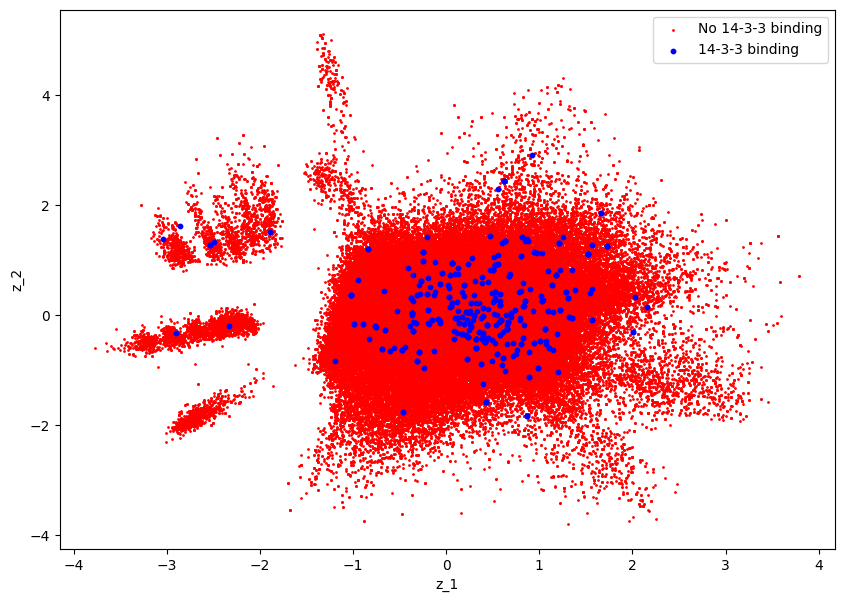

In [21]:
results_for_plot_weights,group = create_results(model_weights, True)
plot(results_for_plot_weights,group, '')

Number of blue dots: 397
Number of red dots: 190565


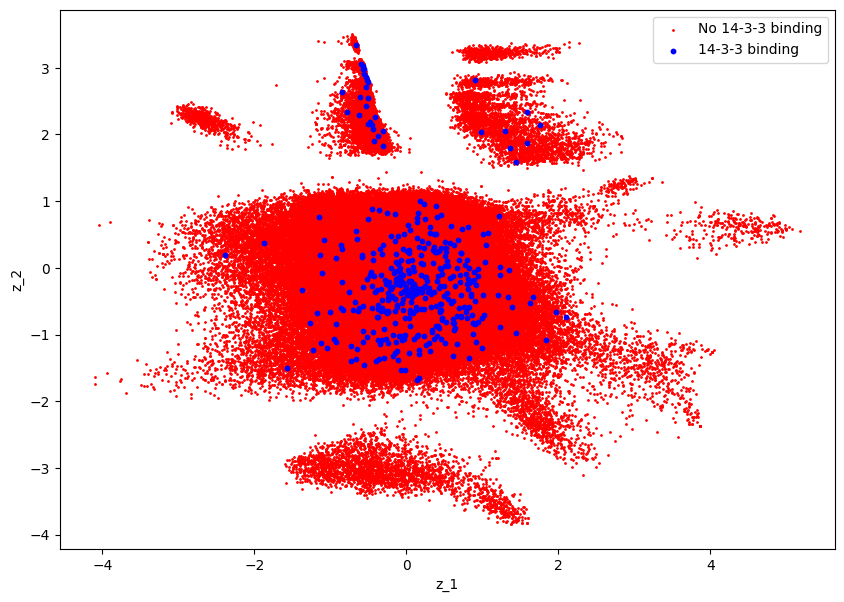

In [22]:
results_for_plot_no_weights,group = create_results(model_no_weights, False)
plot(results_for_plot_no_weights,group, '')